In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# Repo root (so `import src...` works in notebook context)
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from torch_scatter import scatter_mean
from src.model.energy_force_diffusion import EnergyForceDiffusion

# ---- User config ----
# CKPT = "/home/iwe67/PycharmProjects/DrugFlow/runs/energy_force_qm9_dresden_280126_hjb_e_fm/checkpoints/val_loss/epoch_0688_loss_15.170.ckpt"
CKPT = "/home/iwe67/PycharmProjects/DrugFlow/runs/energy_force_OM25_HCNOF_1M_h5_diff_hjb_sigma_small_130326/checkpoints/val_loss/epoch_0176_loss_45.844.ckpt"
OUTDIR = Path("examples/notebook_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

FORCE = "diff" # "total", "diff", "corr"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

print("Repo root:", REPO_ROOT)
print("Using device:", DEVICE)
print("Checkpoint:", CKPT)
print("Output dir:", OUTDIR.resolve())

/home/iwe67/miniforge3/envs/drugflow/lib/python3.11/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


Repo root: /home/iwe67/PycharmProjects/DrugFlow
Using device: cuda
Checkpoint: /home/iwe67/PycharmProjects/DrugFlow/runs/energy_force_OM25_HCNOF_1M_h5_diff_hjb_sigma_small_130326/checkpoints/val_loss/epoch_0176_loss_45.844.ckpt
Output dir: /home/iwe67/PycharmProjects/DrugFlow/notebooks/examples/notebook_outputs


In [2]:
# Load model
device = torch.device(DEVICE)
model = EnergyForceDiffusion.load_from_checkpoint(str(CKPT), map_location=device)
model = model.to(device=device, dtype=DTYPE)
model.eval()

print("Allowed atomic numbers:", model.allowed_atomic_numbers)
print("Diffuse h:", model.diffuse_h)
print("Center ligand:", getattr(model, 'center_ligand', True))
print("Default n_steps:", model.n_steps)

Allowed atomic numbers: [1, 6, 7, 8, 9]
Diffuse h: False
Center ligand: True
Default n_steps: 1000


In [3]:
def split_by_batch_mask(data: torch.Tensor, batch_mask: torch.Tensor) -> list[torch.Tensor]:
    # Preserve order within each sample.
    uniques = torch.unique(batch_mask, sorted=True)
    return [data[batch_mask == i] for i in uniques]


def center_by_batch(x: torch.Tensor, batch_mask: torch.Tensor) -> torch.Tensor:
    # Subtract per-molecule COM.
    com = scatter_mean(x, batch_mask, dim=0)
    return x - com[batch_mask]


def write_xyz(out_path: Path, atomic_numbers: np.ndarray, coords: np.ndarray, comment: str = "") -> None:
    if atomic_numbers.shape[0] != coords.shape[0]:
        raise ValueError("atomic_numbers and coords must have same length")

    # XYZ format: N, comment, then "Element x y z".
    try:
        from rdkit import Chem

        periodic_table = Chem.GetPeriodicTable()
        symbols = [periodic_table.GetElementSymbol(int(z)) for z in atomic_numbers]
    except Exception:
        # Fallback: write atomic numbers as symbols.
        symbols = [str(int(z)) for z in atomic_numbers]

    lines: list[str] = [str(len(symbols)), str(comment or "")]
    for sym, (x, y, z) in zip(symbols, coords):
        lines.append(f"{sym} {x:.6f} {y:.6f} {z:.6f}")
    out_path.write_text("\n".join(lines) + "\n")


def one_hot_from_atomic_numbers(
    atomic_numbers: list[int],
    allowed: list[int],
    *,
    device: torch.device,
    dtype: torch.dtype,
) -> torch.Tensor:
    idx = []
    for z in atomic_numbers:
        if int(z) not in allowed:
            raise ValueError(f"Atomic number {z} not in allowed list {allowed}")
        idx.append(allowed.index(int(z)))
    idx = torch.tensor(idx, device=device, dtype=torch.long)
    return torch.nn.functional.one_hot(idx, num_classes=len(allowed)).to(dtype)


_PRED_V_TO_FORCE_WARNED = False


def get_force_from_pred(
    pred: dict,
    *,
    model: EnergyForceDiffusion,
    x: torch.Tensor,
    batch_mask: torch.Tensor,
    t_flow: torch.Tensor,
    temperature: torch.Tensor | None,
) -> torch.Tensor:
    """Return per-node force (N, x_dim) from a `dynamics()` prediction dict.

    Priority:
      1) `pred['force']` (assumed to already be force)
      2) `pred['v']` / `pred['velocity']` / `pred['vel']` (assumed to be ODE velocity),
         converted to force using VE relation used in sampling:
            v = f + 0.5 * g^2 * F  =>  F = 2 * (v - f) / g^2

    Note: when g^2 ~ 0 (typically at flow time t=1), force is not identifiable from v.
    We set F=0 at those nodes to avoid inf/huge values in plots.
    """
    global _PRED_V_TO_FORCE_WARNED

    F = pred.get("force", None)  # force_fm or force_corr
    if F is not None:
        return F

    # v = None
    # v_key = None
    # for k in ("v", "velocity", "vel"):
    #     if pred.get(k, None) is not None:
    #         v = pred[k]
    #         v_key = k
    #         break
    # if v is None:
    #     raise KeyError("Model predictions did not include 'force' nor any of {'v','velocity','vel'}. ")

    # if not _PRED_V_TO_FORCE_WARNED:
    #     print(f"Info: using pred['{v_key}'] as velocity and converting to force.")
    #     _PRED_V_TO_FORCE_WARNED = True

    # if v.shape[0] != x.shape[0]:
    #     raise ValueError(f"Velocity shape mismatch: v has {v.shape[0]} nodes, x has {x.shape[0]}")

    # # dynamics() takes flow-time t (0 noisy -> 1 clean). Convert to diffusion forward-time tau = 1 - t.
    # tau = 1.0 - t_flow  # (B,1)
    # f = model.module_x._sde_f_forward(x, tau, batch_mask, temperature=temperature).to(dtype=x.dtype)
    # g2 = model.module_x._sde_g2_forward(tau, temperature=temperature)  # (B,)
    # g2_node = g2[batch_mask].unsqueeze(-1).to(dtype=x.dtype)  # (N,1)

    # g2_eps = 1e-8
    # small = g2_node.abs() < g2_eps
    # F = 2.0 * (v.to(dtype=x.dtype) - f) / torch.clamp(g2_node, min=g2_eps)
    # F = torch.where(small, torch.zeros_like(F), F)
    # return F


def unscale_and_unreference_energy_per_graph(
    energy_pred: torch.Tensor,
    one_hot: torch.Tensor,
    batch_mask: torch.Tensor,
    *,
    model: EnergyForceDiffusion,
) -> torch.Tensor:
    """Convert model energy prediction to unscaled, unreferenced (DFT-like) per-graph energy.

    Training uses:
      E_ref = E_DFT - sum_i E_atom(Z_i)
      E_scaled = E_ref / target_sigma

    This function inverts that:
      E_DFT = unreference(unscale(E_scaled)).
    """
    from src import utils as df_utils

    sigma = float(getattr(model, "target_sigma", 1.0))
    elem_ref = getattr(model, "omol_elem_ref", {})

    e = df_utils.unscale_target(energy_pred, sigma)
    e = df_utils.unreference_energy_per_graph(
        e,
        one_hot,
        batch_mask,
        allowed_atomic_numbers=model.allowed_atomic_numbers,
        elem_ref=elem_ref,
    )
    return e


@torch.no_grad()
def sample_ligand_with_energy_trace(
    model: EnergyForceDiffusion,
    *,
    n_samples: int,
    num_nodes: int | torch.Tensor,
    timesteps: int | None = None,
    temperature: float | None = None,
    h_sampler: str = "markov_bridge",
    x_sampler: str = "ode",
    atom_type_prior: str = "uniform",
    stochastic_h: bool = False,
    force_steps: int = 0,
    force_lr: float = 1e-4,  # Learning rate for force-guided steps
) -> dict:
    """Mirror `EnergyForceDiffusion.sample_ligand`, but record predicted energies per step."""
    assert x_sampler in {"ode", "sde"}
    assert h_sampler in {"markov_bridge", "score"}

    device = model.device
    dtype = next(model.parameters()).dtype
    timesteps = int(timesteps or model.n_steps)
    if timesteps <= 0:
        raise ValueError("timesteps must be > 0")

    from src.utils import num_nodes_to_batch_mask

    batch_mask = num_nodes_to_batch_mask(n_samples, num_nodes, device=device)
    if batch_mask.numel() == 0:
        raise ValueError("num_nodes produced empty batch_mask")
    sizes = torch.unique(batch_mask, return_counts=True)[1]

    if not model.use_temperature:
        t_temperature = None
    else:
        if temperature is None:
            temperature = float(model.temperature)
        t_temperature = torch.full((n_samples, 1), float(temperature), device=device, dtype=dtype)

    # Initialize x at the noisiest state (tau=1). In flow time, this corresponds to t=0.
    com = torch.zeros((n_samples, model.x_dim), device=device, dtype=dtype)
    x = model.module_x.sample_z1(com, batch_mask, temperature=t_temperature)

    # h init
    h_initialized = False
    h_logits = None
    h = None

    # Check for custom atom type distribution string
    # Format e.g.: "H:C:N:O:F (fractions)=0.5109:0.3516:0.0580:0.0781:0.0014"
    if isinstance(atom_type_prior, str) and '=' in atom_type_prior and ':' in atom_type_prior:
        try:
            from rdkit import Chem
            pt = Chem.GetPeriodicTable()

            # Divide into Key = Value
            # Remove (fractions) or other notes from key
            lhs, rhs = atom_type_prior.split('=')
            elem_strs = [s.strip() for s in lhs.split('(')[0].split(':')]
            probs = [float(p) for p in rhs.split(':')]

            if len(elem_strs) != len(probs):
                print(f"Warning: Count mismatch in atom_type_prior elements vs probs ({len(elem_strs)} vs {len(probs)}).")
            else:
                # Build probability vector for model.allowed_atomic_numbers
                dist_probs = torch.zeros(model.atom_nf, device=device, dtype=dtype)

                for e_sym, p_val in zip(elem_strs, probs):
                    z = pt.GetAtomicNumber(e_sym)
                    if z in model.allowed_atomic_numbers:
                        idx = model.allowed_atomic_numbers.index(z)
                        dist_probs[idx] = p_val
                    else:
                        print(f"Warning: Element {e_sym} (Z={z}) not in allowed atoms {model.allowed_atomic_numbers}.")

                if dist_probs.sum() > 0:
                    dist_probs = dist_probs / dist_probs.sum()

                    # Sample initial h
                    idx = torch.multinomial(dist_probs, num_samples=batch_mask.shape[0], replacement=True)
                    h = torch.nn.functional.one_hot(idx, num_classes=model.atom_nf).to(dtype)

                    h_initialized = True
                    # h_logits remains None; this works for markov_bridge. For score, we don't infer logits from discrete prior here.
                    if h_sampler != "markov_bridge":
                        print("Warning: Custom prior with h_sampler != 'markov_bridge' may behave unexpectedly (using discrete initialization).")
                else:
                    print("Warning: Custom prior probabilities sum to 0.")

        except ImportError:
            print("Warning: rdkit not found, cannot parse element symbols for custom prior.")
        except Exception as e:
            print(f"Warning: Failed to parse atom_type_prior string '{atom_type_prior}': {e}")

    # Fallback to default initialization if custom wasn't used
    if not h_initialized:
        if not model.diffuse_h:
            if atom_type_prior == "uniform":
                idx = torch.randint(model.atom_nf, (batch_mask.shape[0],), device=device)
            else:
                raise ValueError(f"Unsupported atom_type_prior: {atom_type_prior}")
            h = torch.nn.functional.one_hot(idx, num_classes=model.atom_nf).to(dtype)
            h_logits = None
        else:
            if h_sampler == "markov_bridge":
                h = model.module_h.sample_z0(batch_mask)  # one-hot
                h_logits = None
            else:
                h_logits = model.module_h_score.sample_prior(batch_mask, temperature=t_temperature, dtype=dtype)
                h = model.module_h_score.logits_to_probs(h_logits)

    energies = []  # list of (n_samples,)
    times = []

    dt = 1.0 / float(timesteps)
    for i in range(timesteps):
        # Denoising integration in flow time: start at s=0 and step up to t=1.
        s_val = i * dt
        t_val = (i + 1) * dt
        s = torch.full((n_samples, 1), s_val, device=device, dtype=dtype)
        t = torch.full((n_samples, 1), t_val, device=device, dtype=dtype)

        pred_ligand, _ = model.dynamics(
            x,
            h,
            batch_mask,
            pocket=None,
            t=s,
            temperature=t_temperature,
            bonds_ligand=None,
            sc_transform=None,
        )

        if "energy" not in pred_ligand:
            if i == 0:
                print("Warning: 'energy' not in predictions, filling with 0.0")
            e_graph = torch.zeros(n_samples, device=device, dtype=torch.float32)
        else:
            e = pred_ligand["energy"].to(dtype=torch.float32).view(-1)
            # Support either per-graph or per-node energy.
            if e.numel() == n_samples:
                e_graph = e
            elif e.numel() == batch_mask.numel():
                e_graph = scatter_mean(e, batch_mask, dim=0)
            else:
                raise ValueError(
                    f"Unexpected energy shape: numel={e.numel()} (expected {n_samples} or {batch_mask.numel()})"
                )

            # Convert to DFT-like units for plotting/analysis.
            e_graph = unscale_and_unreference_energy_per_graph(
                e_graph,
                h,
                batch_mask,
                model=model,
            ).to(dtype=torch.float32)

        energies.append(e_graph.detach().cpu().numpy())
        times.append(s_val)

        # Coordinates (flow matching): explicit Euler integration dx/dt = v(x,t).
        # Convert predicted force F into velocity using the ODE relation (VE kinematics):
        #   v = f + 0.5 * g^2 * F
        step = (t - s)[batch_mask]
        F = get_force_from_pred(
            pred_ligand,
            model=model,
            x=x,
            batch_mask=batch_mask,
            t_flow=s,
            temperature=t_temperature,
        )
        
        # --- NEW CODE: Unscale the force to physical units ---
        target_s = float(getattr(model, "target_sigma", 1.0))
        F = F * target_s
        # -----------------------------------------------------

        s_tau = 1.0 - s
        f = model.module_x._sde_f_forward(x, s_tau, batch_mask, temperature=t_temperature).to(dtype=x.dtype)
        g2 = model.module_x._sde_g2_forward(s_tau, temperature=t_temperature)  # (B,)
        g2_node = g2[batch_mask].unsqueeze(-1).to(dtype=x.dtype)
        v = f + 0.5 * g2_node * F.to(dtype=x.dtype)
        x = x + step * v

        if getattr(model, "center_ligand", True):
            x = center_by_batch(x, batch_mask)

        # Update h if diffusing
        if model.diffuse_h:
            if h_sampler == "markov_bridge":
                # Markov-bridge time convention matches flow time (0 noisy -> 1 clean).
                h = model.module_h.sample_zt_given_zs(
                    h,
                    pred_ligand["logits_h"],
                    s=s,
                    t=t,
                    batch_mask=batch_mask,
                )
            else:
                # Logit-score diffusion utilities use diffusion forward-time tau=0 clean -> tau=1 noisy,
                # so we convert from flow-time via tau = 1 - t.
                assert h_logits is not None
                s_tau = 1.0 - s
                t_tau = 1.0 - t
                if x_sampler == "ode":
                    h_logits = model.module_h_score.ode_step(
                        h_logits,
                        pred_ligand["logits_h"],
                        s=s_tau,
                        t=t_tau,
                        batch_mask=batch_mask,
                        temperature=t_temperature,
                    )
                else:
                    h_logits = model.module_h_score.reverse_step(
                        h_logits,
                        pred_ligand["logits_h"],
                        s=s_tau,
                        t=t_tau,
                        batch_mask=batch_mask,
                        temperature=t_temperature,
                        stochastic=stochastic_h,
                    )
                h = model.module_h_score.logits_to_probs(h_logits)

    # Finalize categorical sample
    if model.diffuse_h and h_sampler == "score":
        idx = torch.argmax(h, dim=-1)
        h = torch.nn.functional.one_hot(idx, num_classes=model.atom_nf).to(h.dtype)

    return {
        "x": x,
        "one_hot": h,
        "mask": batch_mask,
        "size": sizes,
        "energy_trace": np.stack(energies, axis=0),  # (timesteps, n_samples)
        "time_trace": np.array(times, dtype=np.float32),
    }


In [4]:
def notebook_forward_combined(
    model: EnergyForceDiffusion,
    x: torch.Tensor,
    h: torch.Tensor,
    batch_mask: torch.Tensor,
    t: torch.Tensor,
    *,
    temperature: torch.Tensor | None,
    correction_active: bool | None = None,
) -> dict:
    if correction_active is None:
        phase_fn = getattr(model, "_phase_name_for_epoch", None)
        if callable(phase_fn):
            correction_active = phase_fn() == "correction"
        else:
            correction_active = hasattr(model, "dynamics_corr") and getattr(model, "dynamics_corr", None) is not None

    pred_diff, pred_corr, pred_total = model._forward_model_components(
        x,
        h,
        batch_mask,
        t,
        temperature=temperature,
        correction_active=bool(correction_active),
    )

    if FORCE == "total":    
        return pred_total
    elif FORCE == "diff":
        return pred_diff
    elif FORCE == "corr":
        return pred_corr
    else:
        error_msg = f"Invalid FORCE value: {FORCE}. Expected one of 'total', 'diff', 'corr'."
        raise ValueError(error_msg)


@torch.no_grad()
def sample_ligand_with_energy_trace(
    model: EnergyForceDiffusion,
    *,
    n_samples: int,
    num_nodes: int | torch.Tensor,
    timesteps: int | None = None,
    temperature: float | None = None,
    h_sampler: str = "markov_bridge",
    x_sampler: str = "sde",
    atom_type_prior: str | dict[str | int, int] = "uniform",
    stochastic_x: bool = True,
    stochastic_h: bool = False,
    force_steps: int = 0,
    force_lr: float = 1e-4,
) -> dict:
    """Notebook sampler aligned with the combined diffusion/correction model."""
    del force_steps, force_lr

    from src import utils as df_utils
    from src.utils import num_nodes_to_batch_mask

    assert x_sampler in {"ode", "sde"}
    assert h_sampler in {"markov_bridge", "score"}

    device = model.device
    dtype = next(model.parameters()).dtype
    timesteps = int(timesteps or model.n_steps)
    if timesteps <= 0:
        raise ValueError("timesteps must be > 0")

    batch_mask = num_nodes_to_batch_mask(n_samples, num_nodes, device=device)
    if batch_mask.numel() == 0:
        raise ValueError("num_nodes produced empty batch_mask")
    sizes = torch.unique(batch_mask, return_counts=True)[1]

    if not model.use_temperature:
        t_temperature = None
    else:
        if temperature is None:
            temperature = float(model.temperature)
        t_temperature = torch.full((n_samples, 1), float(temperature), device=device, dtype=dtype)

    com = torch.zeros((n_samples, model.x_dim), device=device, dtype=dtype)
    x = model.module_x.sample_z1(com, batch_mask, temperature=t_temperature)

    h_initialized = False
    h_logits = None
    h = None
    freeze_atom_types = False

    if isinstance(atom_type_prior, dict):
        try:
            from rdkit import Chem

            periodic_table = Chem.GetPeriodicTable()
        except ImportError:
            periodic_table = None

        if not torch.all(sizes == sizes[0]):
            raise ValueError("Fixed atom counts require the same num_nodes for every sample.")

        expected_nodes = int(sizes[0].item())
        idx_single: list[int] = []
        normalized_counts: dict[int, int] = {}
        for atom_key, count in atom_type_prior.items():
            count = int(count)
            if count < 0:
                raise ValueError(f"Atom count for {atom_key} must be >= 0")

            if isinstance(atom_key, str):
                atom_key = atom_key.strip()
                if atom_key.isdigit():
                    atomic_number = int(atom_key)
                else:
                    if periodic_table is None:
                        raise ImportError(
                            "rdkit is required when fixed atom counts are keyed by element symbols."
                        )
                    atomic_number = int(periodic_table.GetAtomicNumber(atom_key))
                    if atomic_number <= 0:
                        raise ValueError(f"Unknown element symbol: {atom_key}")
            else:
                atomic_number = int(atom_key)

            if atomic_number not in model.allowed_atomic_numbers:
                raise ValueError(
                    f"Atomic number {atomic_number} not in allowed atoms {model.allowed_atomic_numbers}"
                )

            normalized_counts[atomic_number] = normalized_counts.get(atomic_number, 0) + count
            atom_idx = model.allowed_atomic_numbers.index(atomic_number)
            idx_single.extend([atom_idx] * count)

        if len(idx_single) != expected_nodes:
            raise ValueError(
                f"Fixed atom counts sum to {len(idx_single)}, but each sample expects {expected_nodes} atoms"
            )

        idx_single_tensor = torch.tensor(idx_single, device=device, dtype=torch.long)
        idx = torch.cat(
            [idx_single_tensor[torch.randperm(idx_single_tensor.numel(), device=device)] for _ in range(n_samples)],
            dim=0,
        )
        h = torch.nn.functional.one_hot(idx, num_classes=model.atom_nf).to(dtype)
        h_initialized = True
        freeze_atom_types = True
        print(f"Using fixed atom counts per sample: {normalized_counts}")

    if isinstance(atom_type_prior, str) and "=" in atom_type_prior and ":" in atom_type_prior:
        try:
            from rdkit import Chem

            pt = Chem.GetPeriodicTable()
            lhs, rhs = atom_type_prior.split("=")
            elem_strs = [s.strip() for s in lhs.split("(")[0].split(":")]
            probs = [float(p) for p in rhs.split(":")]

            if len(elem_strs) != len(probs):
                print(f"Warning: Count mismatch in atom_type_prior elements vs probs ({len(elem_strs)} vs {len(probs)}).")
            else:
                dist_probs = torch.zeros(model.atom_nf, device=device, dtype=dtype)
                for e_sym, p_val in zip(elem_strs, probs):
                    z = pt.GetAtomicNumber(e_sym)
                    if z in model.allowed_atomic_numbers:
                        idx = model.allowed_atomic_numbers.index(z)
                        dist_probs[idx] = p_val
                    else:
                        print(f"Warning: Element {e_sym} (Z={z}) not in allowed atoms {model.allowed_atomic_numbers}.")

                if dist_probs.sum() > 0:
                    dist_probs = dist_probs / dist_probs.sum()
                    idx = torch.multinomial(dist_probs, num_samples=batch_mask.shape[0], replacement=True)
                    h = torch.nn.functional.one_hot(idx, num_classes=model.atom_nf).to(dtype)
                    h_initialized = True
                    if h_sampler != "markov_bridge":
                        print("Warning: Custom prior with h_sampler != 'markov_bridge' may behave unexpectedly (using discrete initialization).")
                else:
                    print("Warning: Custom prior probabilities sum to 0.")
        except ImportError:
            print("Warning: rdkit not found, cannot parse element symbols for custom prior.")
        except Exception as exc:
            print(f"Warning: Failed to parse atom_type_prior string '{atom_type_prior}': {exc}")

    if not h_initialized:
        if not model.diffuse_h:
            if atom_type_prior == "uniform":
                idx = torch.randint(model.atom_nf, (batch_mask.shape[0],), device=device)
            else:
                raise ValueError(f"Unsupported atom_type_prior: {atom_type_prior}")
            h = torch.nn.functional.one_hot(idx, num_classes=model.atom_nf).to(dtype)
            h_logits = None
        else:
            if h_sampler == "markov_bridge":
                h = model.module_h.sample_z0(batch_mask)
                h_logits = None
            else:
                h_logits = model.module_h_score.sample_prior(batch_mask, temperature=t_temperature, dtype=dtype)
                h = model.module_h_score.logits_to_probs(h_logits)

    energies = []
    times = []
    dt = 1.0 / float(timesteps)
    target_s = float(getattr(model, "target_sigma", 1.0))

    phase_fn = getattr(model, "_phase_name_for_epoch", None)
    correction_active = callable(phase_fn) and phase_fn() == "correction"

    for i in range(timesteps):
        s_val = i * dt
        t_val = (i + 1) * dt
        s = torch.full((n_samples, 1), s_val, device=device, dtype=dtype)
        t = torch.full((n_samples, 1), t_val, device=device, dtype=dtype)

        pred_total = notebook_forward_combined(
            model,
            x,
            h,
            batch_mask,
            s,
            temperature=t_temperature,
            correction_active=correction_active,
        )

        if "energy" not in pred_total:
            if i == 0:
                print("Warning: 'energy' not in predictions, filling with 0.0")
            e_graph = torch.zeros(n_samples, device=device, dtype=torch.float32)
        else:
            e = pred_total["energy"].to(dtype=torch.float32).view(-1)
            if e.numel() == n_samples:
                e_graph = e
            elif e.numel() == batch_mask.numel():
                e_graph = scatter_mean(e, batch_mask, dim=0)
            else:
                raise ValueError(
                    f"Unexpected energy shape: numel={e.numel()} (expected {n_samples} or {batch_mask.numel()})"
                )

            e_graph = unscale_and_unreference_energy_per_graph(
                e_graph,
                h,
                batch_mask,
                model=model,
            ).to(dtype=torch.float32)

        energies.append(e_graph.detach().cpu().numpy())
        times.append(s_val)

        if x_sampler == "ode":
            step = (t - s)[batch_mask]
            force = get_force_from_pred(
                pred_total,
                model=model,
                x=x,
                batch_mask=batch_mask,
                t_flow=s,
                temperature=t_temperature,
            )
            force = df_utils.unscale_target(force.to(dtype=x.dtype), target_s)

            s_tau = 1.0 - s
            drift = model.module_x._sde_f_forward(x, s_tau, batch_mask, temperature=t_temperature).to(dtype=x.dtype)
            g2 = model.module_x._sde_g2_forward(s_tau, temperature=t_temperature)
            g2_node = g2[batch_mask].unsqueeze(-1).to(dtype=x.dtype)
            velocity = drift + 0.5 * g2_node * force
            x = x + step * velocity
        else:
            score_s = get_force_from_pred(
                pred_total,
                model=model,
                x=x,
                batch_mask=batch_mask,
                t_flow=s,
                temperature=t_temperature,
            )
            score_s = df_utils.unscale_target(score_s.to(dtype=x.dtype), target_s)
            s_tau = 1.0 - s
            t_tau = 1.0 - t
            x = model.module_x.reverse_step(
                x,
                score_s,
                s=s_tau,
                t=t_tau,
                batch_mask=batch_mask,
                temperature=t_temperature,
                stochastic=stochastic_x,
            )

        if getattr(model, "center_ligand", True):
            x = center_by_batch(x, batch_mask)

        if model.diffuse_h and not freeze_atom_types:
            if h_sampler == "markov_bridge":
                h = model.module_h.sample_zt_given_zs(
                    h,
                    pred_total["logits_h"],
                    s=s,
                    t=t,
                    batch_mask=batch_mask,
                )
            else:
                assert h_logits is not None
                s_tau = 1.0 - s
                t_tau = 1.0 - t
                if x_sampler == "ode":
                    h_logits = model.module_h_score.ode_step(
                        h_logits,
                        pred_total["logits_h"],
                        s=s_tau,
                        t=t_tau,
                        batch_mask=batch_mask,
                        temperature=t_temperature,
                    )
                else:
                    h_logits = model.module_h_score.reverse_step(
                        h_logits,
                        pred_total["logits_h"],
                        s=s_tau,
                        t=t_tau,
                        batch_mask=batch_mask,
                        temperature=t_temperature,
                        stochastic=stochastic_h,
                    )
                h = model.module_h_score.logits_to_probs(h_logits)

    if model.diffuse_h and h_sampler == "score":
        idx = torch.argmax(h, dim=-1)
        h = torch.nn.functional.one_hot(idx, num_classes=model.atom_nf).to(h.dtype)

    return {
        "x": x,
        "one_hot": h,
        "mask": batch_mask,
        "size": sizes,
        "energy_trace": np.stack(energies, axis=0),
        "time_trace": np.array(times, dtype=np.float32),
    }


def _notebook_dynamics_compat(
    x_atoms: torch.Tensor,
    h_atoms: torch.Tensor,
    mask_atoms: torch.Tensor,
    pocket=None,
    t: torch.Tensor | None = None,
    temperature: torch.Tensor | None = None,
    bonds_ligand=None,
    sc_transform=None,
):
    del pocket, bonds_ligand, sc_transform
    if t is None:
        raise ValueError("Notebook dynamics compatibility wrapper requires t.")
    pred_total = notebook_forward_combined(
        model,
        x_atoms,
        h_atoms,
        mask_atoms,
        t,
        temperature=temperature,
    )
    return pred_total, None


model.dynamics = _notebook_dynamics_compat
print("Notebook helper updated for combined diffusion/correction predictions. Sampling now defaults to stochastic SDE.")

Notebook helper updated for combined diffusion/correction predictions. Sampling now defaults to stochastic SDE.


## Task 1 — Sample a molecule and write `.xyz`
This uses the same sampling loop as `EnergyForceDiffusion.sample_ligand`, and writes an XYZ file to `OUTDIR`.

In [5]:
# Sample 1 molecule (adjust NUM_NODES / TIMESTEPS as desired)
N_SAMPLES = 1
NUM_NODES = 16
TIMESTEPS = 1000
FORCE_STEPS = 0
TEMPERATURE = None  # set e.g. 1.0 to override

# Atom Type Distribution (Prior)
# You can specify a custom ratio string or use 'uniform'.
# The string format must be "Element:Element... (optional)=Prob:Prob..."
ATOM_TYPE_PRIOR = "H:C:N:O:F (fractions)=0.5109:0.3516:0.0580:0.0781:0.0014"
# ATOM_TYPE_PRIOR = "uniform"

batch = sample_ligand_with_energy_trace(
    model,
    n_samples=N_SAMPLES,
    num_nodes=NUM_NODES,
    timesteps=TIMESTEPS,
    temperature=TEMPERATURE,
    force_steps=FORCE_STEPS,
    atom_type_prior=ATOM_TYPE_PRIOR,
    x_sampler='sde',
    stochastic_x=True,
    h_sampler='markov_bridge',
)

coords_list = split_by_batch_mask(batch['x'].detach().cpu(), batch['mask'].detach().cpu())
onehot_list = split_by_batch_mask(batch['one_hot'].detach().cpu(), batch['mask'].detach().cpu())
allowed_z = torch.tensor(model.allowed_atomic_numbers, dtype=torch.long)

i = 0
coords = coords_list[i].numpy()
idx = torch.argmax(onehot_list[i], dim=-1).to(torch.long)
atomic_numbers = allowed_z[idx].numpy()

stem = f'notebook_sample_{i:04d}_n{coords.shape[0]}'
xyz_path = OUTDIR / f'{stem}.xyz'
write_xyz(xyz_path, atomic_numbers=atomic_numbers, coords=coords, comment=stem)
print('Wrote:', xyz_path.resolve())

Wrote: /home/iwe67/PycharmProjects/DrugFlow/notebooks/examples/notebook_outputs/notebook_sample_0000_n16.xyz


## Task 2 — Plot energy vs timestep during sampling
The plot below shows the model-predicted energy at each step (evaluated at flow time $s$ before the Euler update).

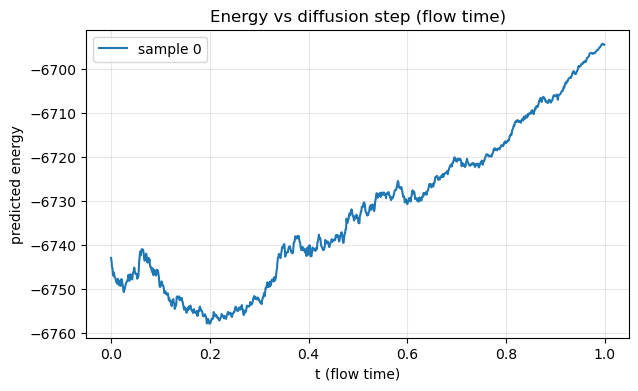

In [6]:
energy_trace = batch['energy_trace']  # (timesteps, n_samples)
time_trace = batch['time_trace']

plt.figure(figsize=(7, 4))
for j in range(energy_trace.shape[1]):
    plt.plot(time_trace, energy_trace[:, j], label=f'sample {j}')
plt.xlabel('t (flow time)')
plt.ylabel('predicted energy')
plt.title('Energy vs diffusion step (flow time)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Task 3 — Water displacement energy heatmaps
We build a water molecule (O,H,H), then displace the **oxygen** atom on an $x$–$y$ grid while keeping $z$ fixed.

To keep this fast, the grid is **batched**: each grid point is treated as a separate 3-atom molecule, so we do one forward pass per requested timestep.

In addition to the energy heatmap, we overlay the model-predicted **force vector field** (on the displaced atom) as a 2D quiver plot.

In [7]:
# Define a simple water geometry (Angstrom-ish scale)
water_z = [8, 1, 1]  # O, H1, H2
water_xyz = np.array([
    [0.0000, 0.0000, 0.0000],   # Oxygen at origin
    [0.9572, 0.0000, 0.0000],   # H1
    [-0.2390, 0.9270, 0.0000],  # H2
], dtype=np.float32)

# Displace O (index 0) in the x-y plane
DISPLACE_ATOM_INDEX = 0

# Define the scan area in ABSOLUTE coordinates (Lab Frame)
GRID_N = 60  # reduce (e.g. 40) if OOM
X_SCAN = (-0.5, 1.0)
Y_SCAN = (-0.5, 1.0)

xs = np.linspace(X_SCAN[0], X_SCAN[1], GRID_N, dtype=np.float32)
ys = np.linspace(Y_SCAN[0], Y_SCAN[1], GRID_N, dtype=np.float32)
XX, YY = np.meshgrid(xs, ys, indexing='xy')
grid_points = np.stack([XX.reshape(-1), YY.reshape(-1)], axis=-1)  # (P,2)
P = grid_points.shape[0]

# Prepare batched water molecules: P molecules, each with 3 atoms
base = torch.tensor(water_xyz, device=device, dtype=DTYPE)  # (3,3)
x_batched = base.unsqueeze(0).repeat(P, 1, 1)  # (P,3,3)

# Overwrite the position of the moving atom with the grid coordinates
x_batched[:, DISPLACE_ATOM_INDEX, 0] = torch.tensor(grid_points[:, 0], device=device, dtype=DTYPE)
x_batched[:, DISPLACE_ATOM_INDEX, 1] = torch.tensor(grid_points[:, 1], device=device, dtype=DTYPE)

# One-hot atom types (single molecule), reused in chunked evaluation
h_onehot_single = one_hot_from_atomic_numbers(water_z, model.allowed_atomic_numbers, device=device, dtype=DTYPE)

# Timesteps to visualize
TS = [1e-3, 0.25, 0.5, 0.75, 1.0]

print(f'Evaluating {P} grid points (GRID_N={GRID_N})...')

Evaluating 3600 grid points (GRID_N=60)...


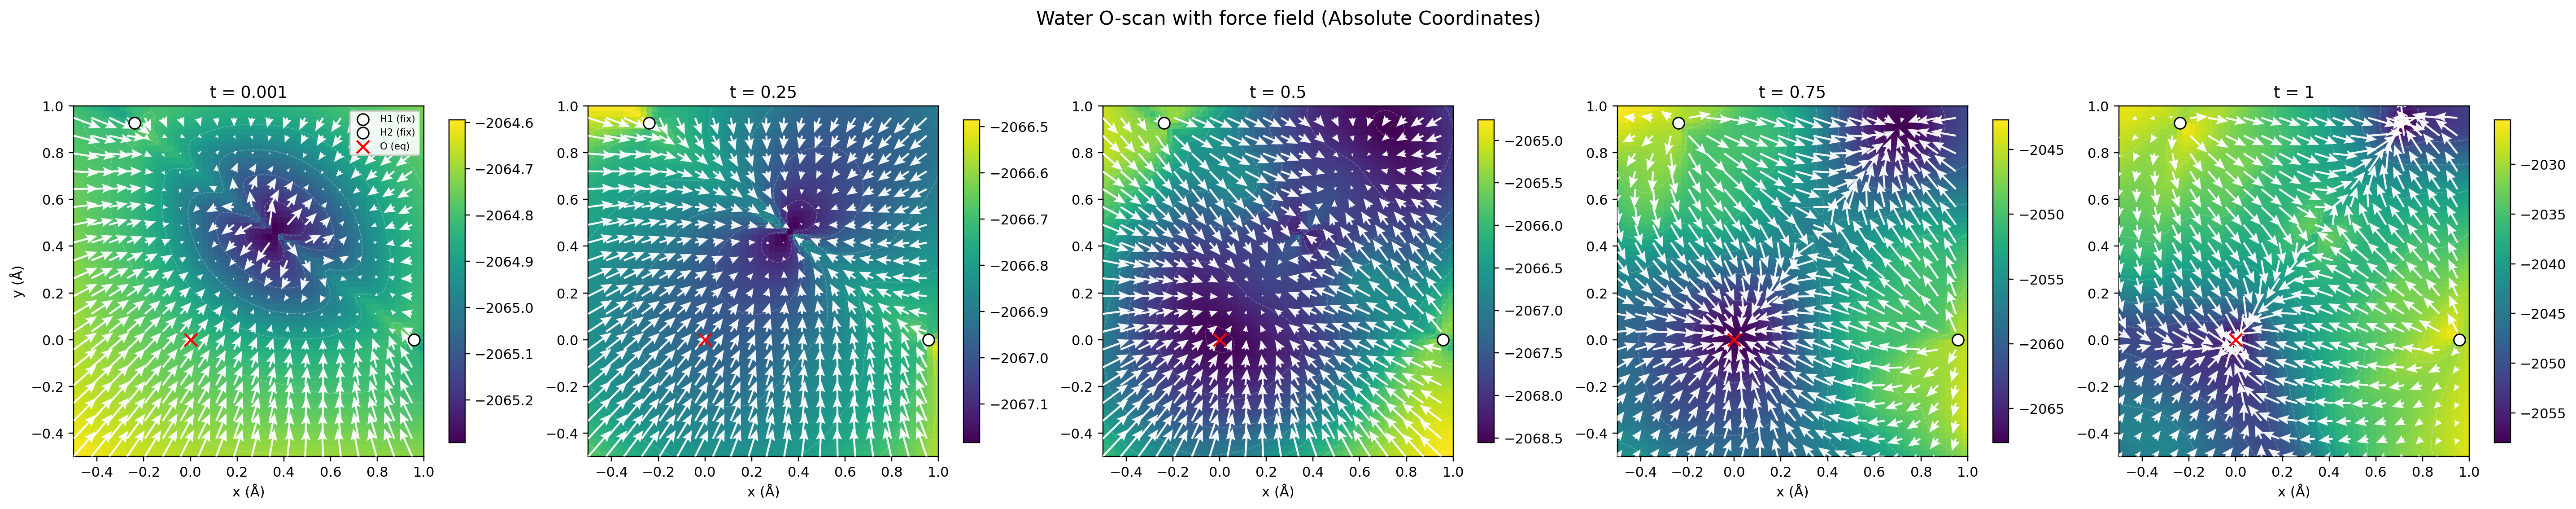

In [8]:
# --- Plotting (chunked to reduce CUDA memory) ---
fig, axes = plt.subplots(
    1, len(TS),
    figsize=(5.2 * len(TS), 5.0),
    constrained_layout=True,
    dpi=220,
 )
axes = np.atleast_1d(axes)

# Reference atoms in ABSOLUTE coords (for scatter overlay)
ref_xy = water_xyz[:, :2]

# How many grid molecules to evaluate per forward pass
CHUNK_MOLS = 512  # reduce if still OOM; increase if you have headroom

# Quiver density target (~20x20 arrows)
QUIVER_STRIDE = max(1, GRID_N // 20)

# If arrows look flipped relative to what you expect, set to -1.0
QUIVER_SIGN = 1.0

for ax, tval in zip(axes, TS):
    e_all = np.empty((P,), dtype=np.float32)
    fx_all = np.empty((P,), dtype=np.float32)
    fy_all = np.empty((P,), dtype=np.float32)

    for start in range(0, P, CHUNK_MOLS):
        end = min(P, start + CHUNK_MOLS)
        chunk_P = end - start

        # Build chunk node tensors on-the-fly to keep peak memory low
        x_chunk = x_batched[start:end].reshape(chunk_P * 3, 3)
        batch_chunk = torch.repeat_interleave(torch.arange(chunk_P, device=device), repeats=3)
        h_chunk = h_onehot_single.unsqueeze(0).repeat(chunk_P, 1, 1).reshape(chunk_P * 3, -1)

        if getattr(model, 'center_ligand', True):
            x_chunk = center_by_batch(x_chunk, batch_chunk)

        t = torch.full((chunk_P, 1), float(tval), device=device, dtype=DTYPE)
        if not model.use_temperature:
            t_temperature_chunk = None
        else:
            t_temperature_chunk = torch.full((chunk_P, 1), float(model.temperature), device=device, dtype=DTYPE)

        with torch.inference_mode():
            pred, _ = model.dynamics(
                x_chunk, h_chunk, batch_chunk, pocket=None, t=t,
                temperature=t_temperature_chunk, bonds_ligand=None, sc_transform=None,
            )
            if 'energy' not in pred:
                raise KeyError("Model predictions did not include 'energy'")
            e = pred['energy'].to(dtype=torch.float32).view(-1)

            if e.numel() == chunk_P:
                e_graph = e
            elif e.numel() == batch_chunk.numel():
                e_graph = scatter_mean(e, batch_chunk, dim=0)
            else:
                raise ValueError(f'Unexpected energy shape: {e.numel()}')

            # Convert to DFT-like units (unscale + unreference)
            e_graph = unscale_and_unreference_energy_per_graph(
                e_graph,
                h_chunk,
                batch_chunk,
                model=model,
            ).to(dtype=torch.float32)

            F = get_force_from_pred(
                pred,
                model=model,
                x=x_chunk,
                batch_mask=batch_chunk,
                t_flow=t,
                temperature=t_temperature_chunk,
            ).to(dtype=torch.float32)
            if F.shape[0] != batch_chunk.numel():
                raise ValueError(f"Unexpected force shape: {tuple(F.shape)} (expected ({batch_chunk.numel()}, {x_chunk.shape[1]}))")

            # Extract force on the displaced atom for each molecule in the chunk
            moving_node_idx = torch.arange(chunk_P, device=device) * 3 + int(DISPLACE_ATOM_INDEX)
            F_moving = F[moving_node_idx, :2]  # (chunk_P, 2)

        e_all[start:end] = e_graph.detach().cpu().numpy()
        fx_all[start:end] = F_moving[:, 0].detach().cpu().numpy()
        fy_all[start:end] = F_moving[:, 1].detach().cpu().numpy()

    heat = e_all.reshape(GRID_N, GRID_N)
    fx = fx_all.reshape(GRID_N, GRID_N)
    fy = fy_all.reshape(GRID_N, GRID_N)

    # Plot using ABSOLUTE coordinates in extent
    im = ax.imshow(
        heat,
        origin='lower',
        extent=(X_SCAN[0], X_SCAN[1], Y_SCAN[0], Y_SCAN[1]),
        aspect='equal',  # Ensure physical aspect ratio
        cmap='viridis',
    )

    # Overlay fixed atoms + equilibrium position of the moving atom
    ax.scatter(ref_xy[1, 0], ref_xy[1, 1], c='white', s=70, edgecolors='k', label='H1 (fix)', zorder=5)
    ax.scatter(ref_xy[2, 0], ref_xy[2, 1], c='white', s=70, edgecolors='k', label='H2 (fix)', zorder=5)
    ax.scatter(ref_xy[0, 0], ref_xy[0, 1], c='red', marker='x', s=85, label='O (eq)', zorder=6)

    # Force vector field (downsampled)
    Xq = XX[::QUIVER_STRIDE, ::QUIVER_STRIDE]
    Yq = YY[::QUIVER_STRIDE, ::QUIVER_STRIDE]
    Uq = QUIVER_SIGN * fx[::QUIVER_STRIDE, ::QUIVER_STRIDE]
    Vq = QUIVER_SIGN * fy[::QUIVER_STRIDE, ::QUIVER_STRIDE]
    mag = np.sqrt(Uq * Uq + Vq * Vq)
    grid_step = max(
        (X_SCAN[1] - X_SCAN[0]) / max(1, GRID_N - 1),
        (Y_SCAN[1] - Y_SCAN[0]) / max(1, GRID_N - 1),
    )
    mag95 = float(np.nanpercentile(mag, 95)) if np.isfinite(mag).any() else 0.0
    scale = (mag95 / (grid_step * 5)) if mag95 > 0 else 1.0
    ax.quiver(
        Xq, Yq, Uq, Vq,
        angles='xy', scale_units='xy', scale=scale,
        color='white', alpha=0.95,
        width=0.0055, headwidth=5.0, headlength=6.0, headaxislength=5.2,
        zorder=4,
    )

    ax.set_title(f't = {tval:g}')
    ax.set_xlabel('x (Å)')
    if ax is axes[0]:
        ax.set_ylabel('y (Å)')
        ax.legend(loc='upper right', fontsize='x-small', framealpha=0.9)

    ax.contour(XX, YY, heat, colors='white', alpha=0.25, linewidths=0.6)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Water O-scan with force field (Absolute Coordinates)', y=1.05, fontsize=14)
plt.show()

## Task 3b — CH$_4$ hydrogen displacement energy heatmaps
We build a methane (CH$_4$) molecule in a simple tetrahedral geometry, then displace **one H atom** on an $x$–$y$ grid (with $z$ fixed) while keeping the other atoms fixed.

As with the water scan, the grid is **batched**: each grid point is treated as a separate molecule so we need only one forward pass per requested timestep.

We also overlay the model-predicted **force vector field** (on the displaced H) as a 2D quiver plot.

Evaluating 3600 grid points (CH4_GRID_N=60)...


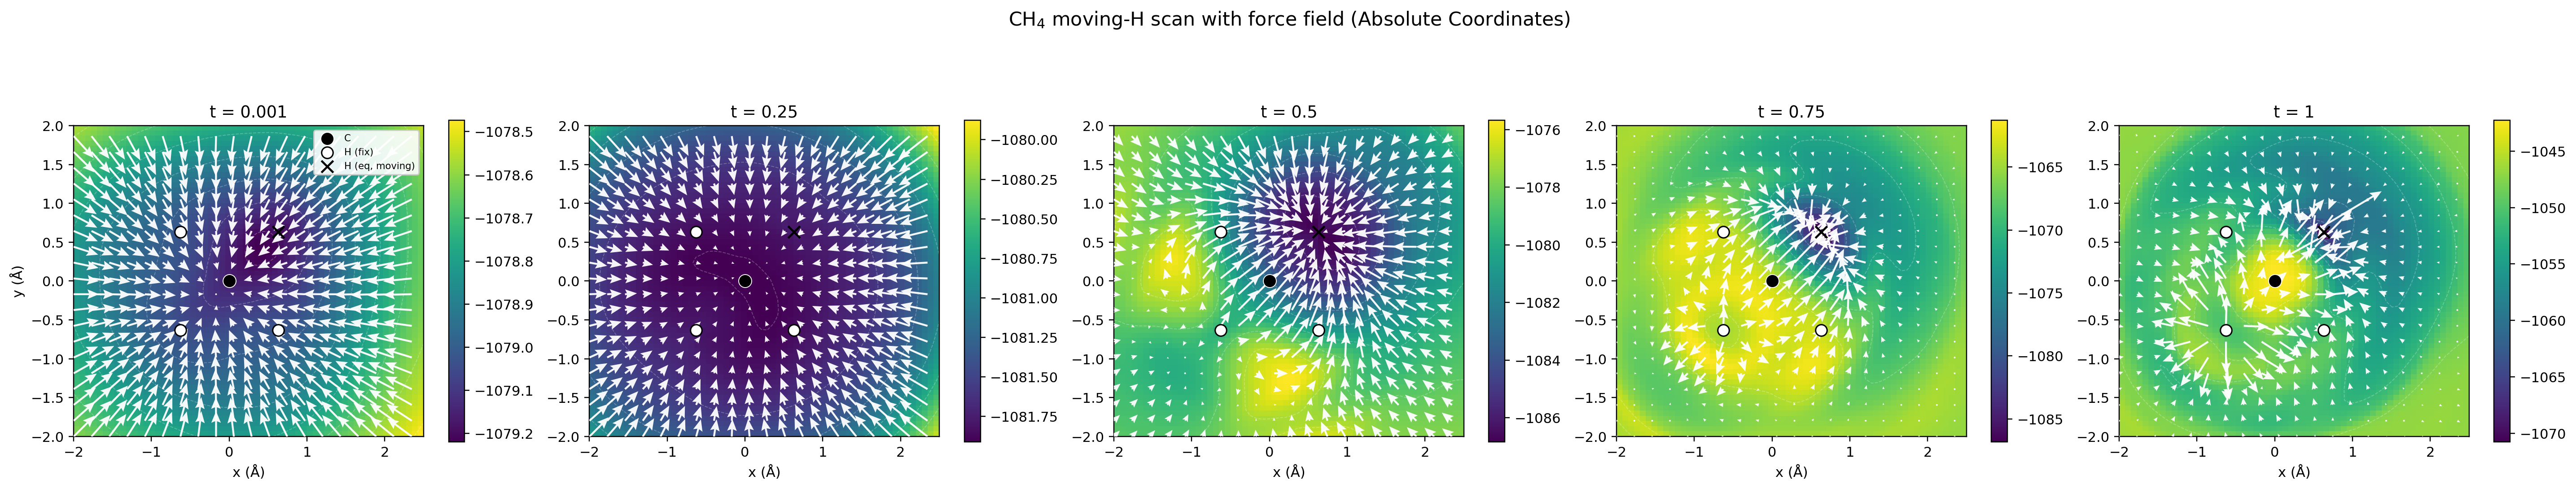

In [9]:
# --- CH4 scan: displace one hydrogen in x-y plane (chunked to reduce CUDA memory) ---

# Atom ordering: C, H1, H2, H3, H4
CH4_Z = [6, 1, 1, 1, 1]

# Simple tetrahedral geometry: place C at origin, H's at tetrahedron corners
# using bond length ~1.09 Å.
ch_bond = 1.09
tet = np.array(
    [
        [1.0, 1.0, 1.0],
        [1.0, -1.0, -1.0],
        [-1.0, 1.0, -1.0],
        [-1.0, -1.0, 1.0],
    ],
    dtype=np.float32,
 )
tet = tet / np.linalg.norm(tet[0])  # normalize by sqrt(3)
H_pos = ch_bond * tet  # (4,3)

CH4_XYZ = np.vstack([np.zeros((1, 3), dtype=np.float32), H_pos]).astype(np.float32)  # (5,3)

# Displace one hydrogen (choose H1, index 1) in the x-y plane
CH4_DISPLACE_ATOM_INDEX = 1

# Scan area in ABSOLUTE coordinates (lab frame)
CH4_GRID_N = 60  # reduce if OOM, e.g. 40
CH4_X_SCAN = (-2.0, 2.5)
CH4_Y_SCAN = (-2.0, 2.0)

ch4_xs = np.linspace(CH4_X_SCAN[0], CH4_X_SCAN[1], CH4_GRID_N, dtype=np.float32)
ch4_ys = np.linspace(CH4_Y_SCAN[0], CH4_Y_SCAN[1], CH4_GRID_N, dtype=np.float32)
CH4_XX, CH4_YY = np.meshgrid(ch4_xs, ch4_ys, indexing='xy')
ch4_grid_points = np.stack([CH4_XX.reshape(-1), CH4_YY.reshape(-1)], axis=-1)  # (P,2)
ch4_P = ch4_grid_points.shape[0]

# Base geometry and batched molecules
ch4_base = torch.tensor(CH4_XYZ, device=device, dtype=DTYPE)  # (N,3)
ch4_n_atoms = ch4_base.shape[0]
ch4_x_batched = ch4_base.unsqueeze(0).repeat(ch4_P, 1, 1)  # (P,N,3)

# Overwrite the position of the moving H with the grid coordinates (z fixed at equilibrium z)
ch4_x_batched[:, CH4_DISPLACE_ATOM_INDEX, 0] = torch.tensor(ch4_grid_points[:, 0], device=device, dtype=DTYPE)
ch4_x_batched[:, CH4_DISPLACE_ATOM_INDEX, 1] = torch.tensor(ch4_grid_points[:, 1], device=device, dtype=DTYPE)

# One-hot atom types (single molecule), reused for all chunks
ch4_h_onehot_single = one_hot_from_atomic_numbers(CH4_Z, model.allowed_atomic_numbers, device=device, dtype=DTYPE)

# Timesteps to visualize
CH4_TS = [1e-3, 0.25, 0.5, 0.75, 1.0]

# Reference atoms in ABSOLUTE coords (for scatter overlay)
ref_xy = CH4_XYZ[:, :2]

# How many grid molecules to evaluate per forward pass
CH4_CHUNK_MOLS = 256  # reduce if still OOM

# Quiver density target (~20x20 arrows)
CH4_QUIVER_STRIDE = max(1, CH4_GRID_N // 20)

# If arrows look flipped relative to what you expect, set to -1.0
QUIVER_SIGN = 1.0

print(f'Evaluating {ch4_P} grid points (CH4_GRID_N={CH4_GRID_N})...')

fig, axes = plt.subplots(
    1, len(CH4_TS),
    figsize=(5.2 * len(CH4_TS), 5.0),
    constrained_layout=True,
    dpi=220,
 )
axes = np.atleast_1d(axes)

for ax, tval in zip(axes, CH4_TS):
    e_all = np.empty((ch4_P,), dtype=np.float32)
    fx_all = np.empty((ch4_P,), dtype=np.float32)
    fy_all = np.empty((ch4_P,), dtype=np.float32)

    for start in range(0, ch4_P, CH4_CHUNK_MOLS):
        end = min(ch4_P, start + CH4_CHUNK_MOLS)
        chunk_P = end - start

        x_chunk = ch4_x_batched[start:end].reshape(chunk_P * ch4_n_atoms, 3)
        batch_chunk = torch.repeat_interleave(torch.arange(chunk_P, device=device), repeats=ch4_n_atoms)
        h_chunk = ch4_h_onehot_single.unsqueeze(0).repeat(chunk_P, 1, 1).reshape(chunk_P * ch4_n_atoms, -1)

        if getattr(model, 'center_ligand', True):
            x_chunk = center_by_batch(x_chunk, batch_chunk)

        t = torch.full((chunk_P, 1), float(tval), device=device, dtype=DTYPE)
        if not model.use_temperature:
            t_temperature_chunk = None
        else:
            t_temperature_chunk = torch.full((chunk_P, 1), float(model.temperature), device=device, dtype=DTYPE)

        with torch.inference_mode():
            pred, _ = model.dynamics(
                x_chunk, h_chunk, batch_chunk, pocket=None, t=t,
                temperature=t_temperature_chunk, bonds_ligand=None, sc_transform=None,
            )
            if 'energy' not in pred:
                raise KeyError("Model predictions did not include 'energy'")
            e = pred['energy'].to(dtype=torch.float32).view(-1)

            if e.numel() == chunk_P:
                e_graph = e
            elif e.numel() == batch_chunk.numel():
                e_graph = scatter_mean(e, batch_chunk, dim=0)
            else:
                raise ValueError(f'Unexpected energy shape: {e.numel()}')

            # Convert to DFT-like units (unscale + unreference)
            e_graph = unscale_and_unreference_energy_per_graph(
                e_graph,
                h_chunk,
                batch_chunk,
                model=model,
            ).to(dtype=torch.float32)

            F = get_force_from_pred(
                pred,
                model=model,
                x=x_chunk,
                batch_mask=batch_chunk,
                t_flow=t,
                temperature=t_temperature_chunk,
            ).to(dtype=torch.float32)
            if F.shape[0] != batch_chunk.numel():
                raise ValueError(f"Unexpected force shape: {tuple(F.shape)} (expected ({batch_chunk.numel()}, {x_chunk.shape[1]}))")

            moving_node_idx = torch.arange(chunk_P, device=device) * ch4_n_atoms + int(CH4_DISPLACE_ATOM_INDEX)
            F_moving = F[moving_node_idx, :2]  # (chunk_P, 2)

        e_all[start:end] = e_graph.detach().cpu().numpy()
        fx_all[start:end] = F_moving[:, 0].detach().cpu().numpy()
        fy_all[start:end] = F_moving[:, 1].detach().cpu().numpy()

    heat = e_all.reshape(CH4_GRID_N, CH4_GRID_N)
    fx = fx_all.reshape(CH4_GRID_N, CH4_GRID_N)
    fy = fy_all.reshape(CH4_GRID_N, CH4_GRID_N)

    im = ax.imshow(
        heat,
        origin='lower',
        extent=(CH4_X_SCAN[0], CH4_X_SCAN[1], CH4_Y_SCAN[0], CH4_Y_SCAN[1]),
        aspect='equal',
        cmap='viridis',
    )

    # Overlay fixed atoms + equilibrium position of the moving H
    ax.scatter(ref_xy[0, 0], ref_xy[0, 1], c='k', s=90, edgecolors='w', linewidths=0.6, label='C', zorder=6)

    # fixed H's (all except moving index)
    fixed_h_idx = [2, 3, 4]
    ax.scatter(ref_xy[fixed_h_idx, 0], ref_xy[fixed_h_idx, 1], c='white', s=70, edgecolors='k', label='H (fix)', zorder=6)

    # moving H equilibrium position
    ax.scatter(ref_xy[CH4_DISPLACE_ATOM_INDEX, 0], ref_xy[CH4_DISPLACE_ATOM_INDEX, 1], c='k', marker='x', s=75, label='H (eq, moving)', zorder=7)

    # Force vector field (downsampled)
    Xq = CH4_XX[::CH4_QUIVER_STRIDE, ::CH4_QUIVER_STRIDE]
    Yq = CH4_YY[::CH4_QUIVER_STRIDE, ::CH4_QUIVER_STRIDE]
    Uq = QUIVER_SIGN * fx[::CH4_QUIVER_STRIDE, ::CH4_QUIVER_STRIDE]
    Vq = QUIVER_SIGN * fy[::CH4_QUIVER_STRIDE, ::CH4_QUIVER_STRIDE]
    mag = np.sqrt(Uq * Uq + Vq * Vq)
    grid_step = max(
        (CH4_X_SCAN[1] - CH4_X_SCAN[0]) / max(1, CH4_GRID_N - 1),
        (CH4_Y_SCAN[1] - CH4_Y_SCAN[0]) / max(1, CH4_GRID_N - 1),
    )
    mag95 = float(np.nanpercentile(mag, 95)) if np.isfinite(mag).any() else 0.0
    scale = (mag95 / (5.0 * grid_step)) if mag95 > 0 else 1.0
    ax.quiver(
        Xq, Yq, Uq, Vq,
        angles='xy', scale_units='xy', scale=scale,
        color='white', alpha=0.95,
        width=0.0055, headwidth=5.0, headlength=6.0, headaxislength=5.2,
        zorder=4,
    )

    ax.set_title(f't = {tval:g}')
    ax.set_xlabel('x (Å)')
    if ax is axes[0]:
        ax.set_ylabel('y (Å)')
        ax.legend(loc='upper right', fontsize='x-small', framealpha=0.9)

    ax.contour(CH4_XX, CH4_YY, heat, colors='white', alpha=0.25, linewidths=0.6)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('CH$_4$ moving-H scan with force field (Absolute Coordinates)', y=1.05, fontsize=14)
plt.show()

## Task 4 — Boltzmann Distribution Analysis
We sample a larger batch of molecules and analyze the distribution of their final predicted energies. If the generative model has learned to sample from the Boltzmann distribution $p(x) \propto e^{-E(x)/T}$, the tail of the energy histogram should decay exponentially (linear in log-density).


Task 4: Sampling 512 molecules (n=9) with fixed atom counts {'H': 5, 'C': 2, 'N': 1, 'O': 1, 'F': 0} to analyze energy distribution...
Using fixed atom counts per sample: {1: 5, 6: 2, 7: 1, 8: 1, 9: 0}


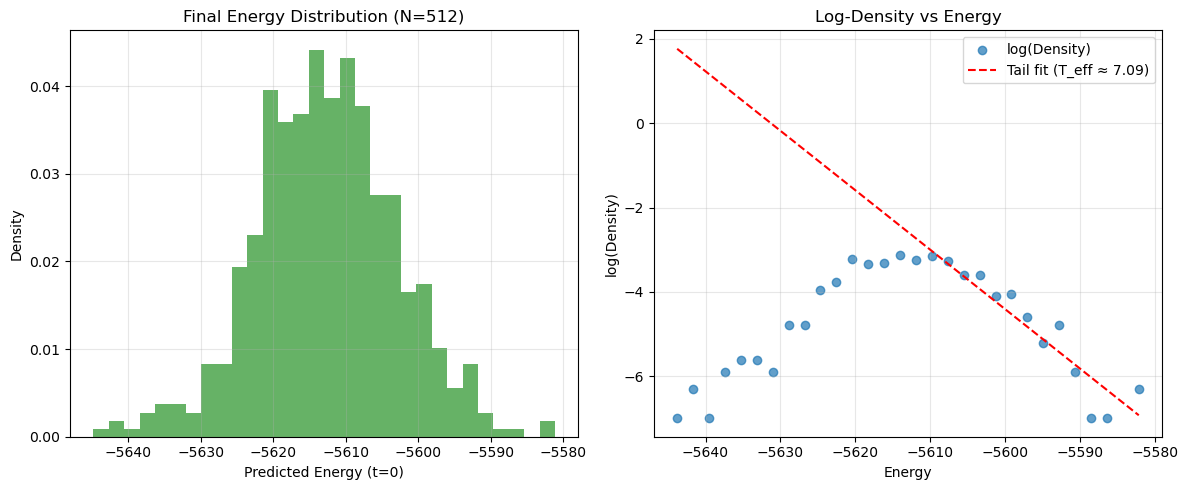

Mean Final Energy: -5612.7012 +/- 9.6305
Min: -5644.8418, Max: -5581.1479


In [11]:
# Task 4 Configuration
T4_N_SAMPLES = 512
T4_FIXED_ATOM_COUNTS = {"H": 5, "C": 2, "N": 1, "O": 1, "F": 0}
T4_NUM_NODES = sum(T4_FIXED_ATOM_COUNTS.values())
T4_TIMESTEPS = 100
T4_TEMPERATURE = None  # None uses model default

print(
    f"Task 4: Sampling {T4_N_SAMPLES} molecules (n={T4_NUM_NODES}) "
    f"with fixed atom counts {T4_FIXED_ATOM_COUNTS} to analyze energy distribution..."
)

# 1. Generate samples
batch_t4 = sample_ligand_with_energy_trace(
    model,
    n_samples=T4_N_SAMPLES,
    num_nodes=T4_NUM_NODES,
    timesteps=T4_TIMESTEPS,
    temperature=T4_TEMPERATURE,
    atom_type_prior=T4_FIXED_ATOM_COUNTS,
    x_sampler='sde',
    stochastic_x=True,
    h_sampler='markov_bridge',
)

# 2. Extract final energies (from the energy trace at the last step, t=0)
# energy_trace shape is (timesteps, n_samples)
# The last entry corresponds to s=0.0 (end of generation)
final_energies = batch_t4['energy_trace'][-1, :]

# 3. Analyze and Plot
from scipy.optimize import curve_fit

def boltzmann_pdf(E, T_eff, C):
    # p(E) ~ exp(-E / T_eff) * g(E) ?
    # Usually we plot histogram of E. If samples x ~ exp(-E(x)/T),
    # the distribution of E values P(E) depends on density of states g(E).
    # P(E) = g(E) exp(-E/T)
    # For a simple harmonic analysis around minima, this looks like a Gamma / Chi-chi dist.
    # But often checking log P(E) vs E linearity is a quick check for Boltzmann tail.
    return C * np.exp(-E / T_eff)

plt.figure(figsize=(12, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
counts, bins, patches = plt.hist(final_energies, bins=30, density=True, alpha=0.6, color='g', label='Sampled E')
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Fit exponential tail to the right side of the peak?
# Or just plot simple exponential decay if appropriate.
# Here we just visualize the distribution.
plt.title(f'Final Energy Distribution (N={T4_N_SAMPLES})')
plt.xlabel('Predicted Energy (t=0)')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)

# Subplot 2: Log-prob plot (Boltzmann check)
# If p(x) ~ exp(-E(x)/T), then usually high E tails fall off exponentially.
# log P(E) vs E should be linear with slope -1/T for high E (ignoring DOS effects).
plt.subplot(1, 2, 2)
# Filter bins with non-zero counts
valid = counts > 0
log_counts = np.log(counts[valid])
valid_centers = bin_centers[valid]

plt.scatter(valid_centers, log_counts, alpha=0.7, label='log(Density)')

# Simple linear fit to the tail (e.g. above median energy) to estimate effective T
median_E = np.median(final_energies)
tail_mask = valid_centers > median_E
if tail_mask.sum() > 2:
    slope, intercept = np.polyfit(valid_centers[tail_mask], log_counts[tail_mask], 1)
    T_est = -1.0 / slope
    plt.plot(valid_centers, slope * valid_centers + intercept, 'r--', label=f'Tail fit (T_eff ≈ {T_est:.2f})')

plt.title('Log-Density vs Energy')
plt.xlabel('Energy')
plt.ylabel('log(Density)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Final Energy: {np.mean(final_energies):.4f} +/- {np.std(final_energies):.4f}")
print(f"Min: {np.min(final_energies):.4f}, Max: {np.max(final_energies):.4f}")

## Task 5 — Evaluate Energy on External Dataset
We load a small batch of ground truth data using `src.data.pkl_dataset.PKLEnergyForceDataset` and evaluate the model's energy prediction against the ground truth labels.

**Note**: You must set `DATASET_DIR` to a folder containing `.pkl` files with `pos`, `atomic_numbers`, `e_total`, and `forces`.

Loading data from /home/iwe67/qm9_dataset_EBDM/qm9_pkl...
Found 512 samples in dataset.
Batch loaded: 128 molecules
Batch MAE: 5.3398
Batch MSE: 47.7609
Correlation: 1.0000


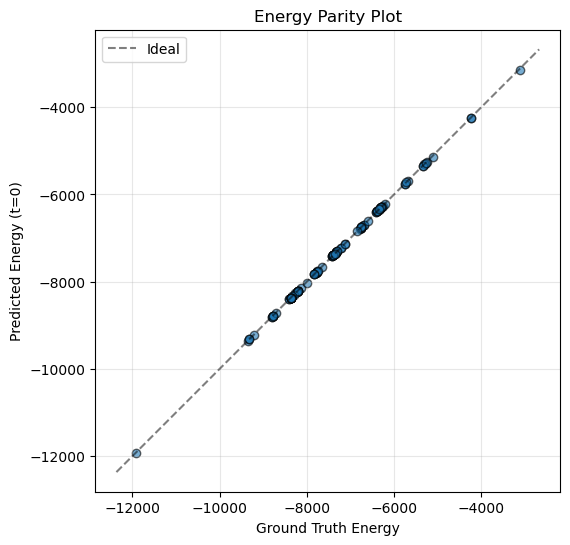

In [ ]:
# Task 5: Evaluate Energy on External Dataset

from torch.utils.data import DataLoader
from src.data.pkl_dataset import PKLEnergyForceDataset

# ---- Configuration ----
# REPLACE with your dataset path containing .pkl files
DATASET_DIR = Path("/home/iwe67/qm9_dataset_EBDM/qm9_pkl/") 
# DATASET_DIR = Path("/media/data/qm_dataset/fairchem/HCNOF_OM25_2-50_4M/")
BATCH_SIZE_T5 = 128
LIMIT_T5 = 512 
Eh_2_eV_DATASET = True

if not DATASET_DIR.exists() or not DATASET_DIR.is_dir():
    print(f"Dataset directory '{DATASET_DIR}' not found or is not a directory.")
    print("Please update DATASET_DIR in the cell above to point to a valid folder of .pkl files.")
else:
    print(f"Loading data from {DATASET_DIR}...")
    
    # 1. Create Dataset
    # We use the model's allowed atomic numbers
    dataset = PKLEnergyForceDataset(
        data_dir=DATASET_DIR,
        atom_types_format="atomic_numbers",
        allowed_atomic_numbers=model.allowed_atomic_numbers,
        file_limit=LIMIT_T5,
        device='cpu' # Load data on CPU initially
    )
    
    print(f"Found {len(dataset)} samples in dataset.")
    
    if len(dataset) == 0:
        print(f"No .pkl files found in {DATASET_DIR}. Please check the path and file extensions.")
    else:
        # 2. Create DataLoader
        # Use the static collate_fn from the dataset class
        loader = DataLoader(
            dataset, 
            batch_size=BATCH_SIZE_T5, 
            collate_fn=PKLEnergyForceDataset.collate_fn,
            shuffle=True
        )
        
        # 3. Get one batch
        try:
            batch = next(iter(loader))
            print(f"Batch loaded: {len(batch['ligand']['size'])} molecules")
            
            # Helper to move batch to device
            def to_device(x, dev):
                if isinstance(x, torch.Tensor):
                    return x.to(dev)
                elif isinstance(x, dict):
                    return {k: to_device(v, dev) for k, v in x.items()}
                return x
            
            batch = to_device(batch, device)
            
            ligand = batch['ligand']
            energy_gt = batch['energy'].to(dtype=torch.float32).view(-1)
            if Eh_2_eV_DATASET:
                energy_gt = energy_gt * 27.2114
            
            # 4. Evaluate Model at t=0
            # Clean data corresponds to t=0 (or close to it depending on definition, here we use t=0)
            t_zeros = torch.zeros((energy_gt.shape[0], 1), device=device, dtype=DTYPE) 
            
            if model.use_temperature:
                t_temp = torch.full((energy_gt.shape[0], 1), float(model.temperature), device=device, dtype=DTYPE)
            else:
                t_temp = None

            with torch.no_grad():
                pred, _ = model.dynamics(
                    x_atoms=ligand['x'],
                    h_atoms=ligand['one_hot'],
                    mask_atoms=ligand['mask'],
                    pocket=None,
                    t=t_zeros,
                    temperature=t_temp
                )

            # Model may output per-graph or per-node energy; normalize to per-graph.
            e = pred['energy'].to(dtype=torch.float32).view(-1)
            if e.numel() == energy_gt.shape[0]:
                e_graph = e
            elif e.numel() == ligand['mask'].numel():
                e_graph = scatter_mean(e, ligand['mask'], dim=0)
            else:
                raise ValueError(f"Unexpected energy shape: numel={e.numel()} (expected {energy_gt.shape[0]} or {ligand['mask'].numel()})")

            # Convert predicted energies to unscaled + unreferenced units to match dataset energies.
            energy_pred = unscale_and_unreference_energy_per_graph(
                e_graph,
                ligand['one_hot'],
                ligand['mask'],
                model=model,
            ).to(dtype=torch.float32)
            
            # 5. Metrics
            mae = (energy_pred - energy_gt).abs().mean().item()
            mse = ((energy_pred - energy_gt)**2).mean().item()
            corr = np.corrcoef(energy_gt.detach().cpu().numpy(), energy_pred.detach().cpu().numpy())[0, 1]
            
            print(f"Batch MAE: {mae:.4f}")
            print(f"Batch MSE: {mse:.4f}")
            print(f"Correlation: {corr:.4f}")
            
            # 6. Plot
            plt.figure(figsize=(6,6))
            plt.scatter(energy_gt.detach().cpu().numpy(), energy_pred.detach().cpu().numpy(), alpha=0.6, edgecolors='k')
            
            # Plot reference line
            all_vals = torch.cat([energy_gt, energy_pred])
            min_val, max_val = all_vals.min().item(), all_vals.max().item()
            pad = (max_val - min_val) * 0.05
            plt.plot([min_val-pad, max_val+pad], [min_val-pad, max_val+pad], 'k--', alpha=0.5, label='Ideal')
            
            plt.xlabel("Ground Truth Energy")
            plt.ylabel("Predicted Energy (t=0)")
            plt.title("Energy Parity Plot")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.axis('equal')
            plt.show()
            
        except Exception as e:
            print(f"Error processing batch: {e}")
            import traceback
            traceback.print_exc()

## Task 6: compare diffusion-force vs total-force vector norms along a CH4 noising trajectory

Correction active: True
Using 30 trajectory steps (flow time t: 0 noisy -> t_end clean-like).
t0_time_epsilon = 0.001000 -> evaluation endpoint t_end = 0.999000
Diffusion-force physical scaling enabled: False
Diffusion-force temperature for scaling: 300.00 K
Diffusion-force multiplicative scale k_B T: 1.00000000
Endpoint data (t=0.999000): mean ||F_diff||  = 15.551416
Endpoint data (t=0.999000): mean ||F_total|| = 0.375931
Endpoint data (t=0.999000): difference       = -15.175486


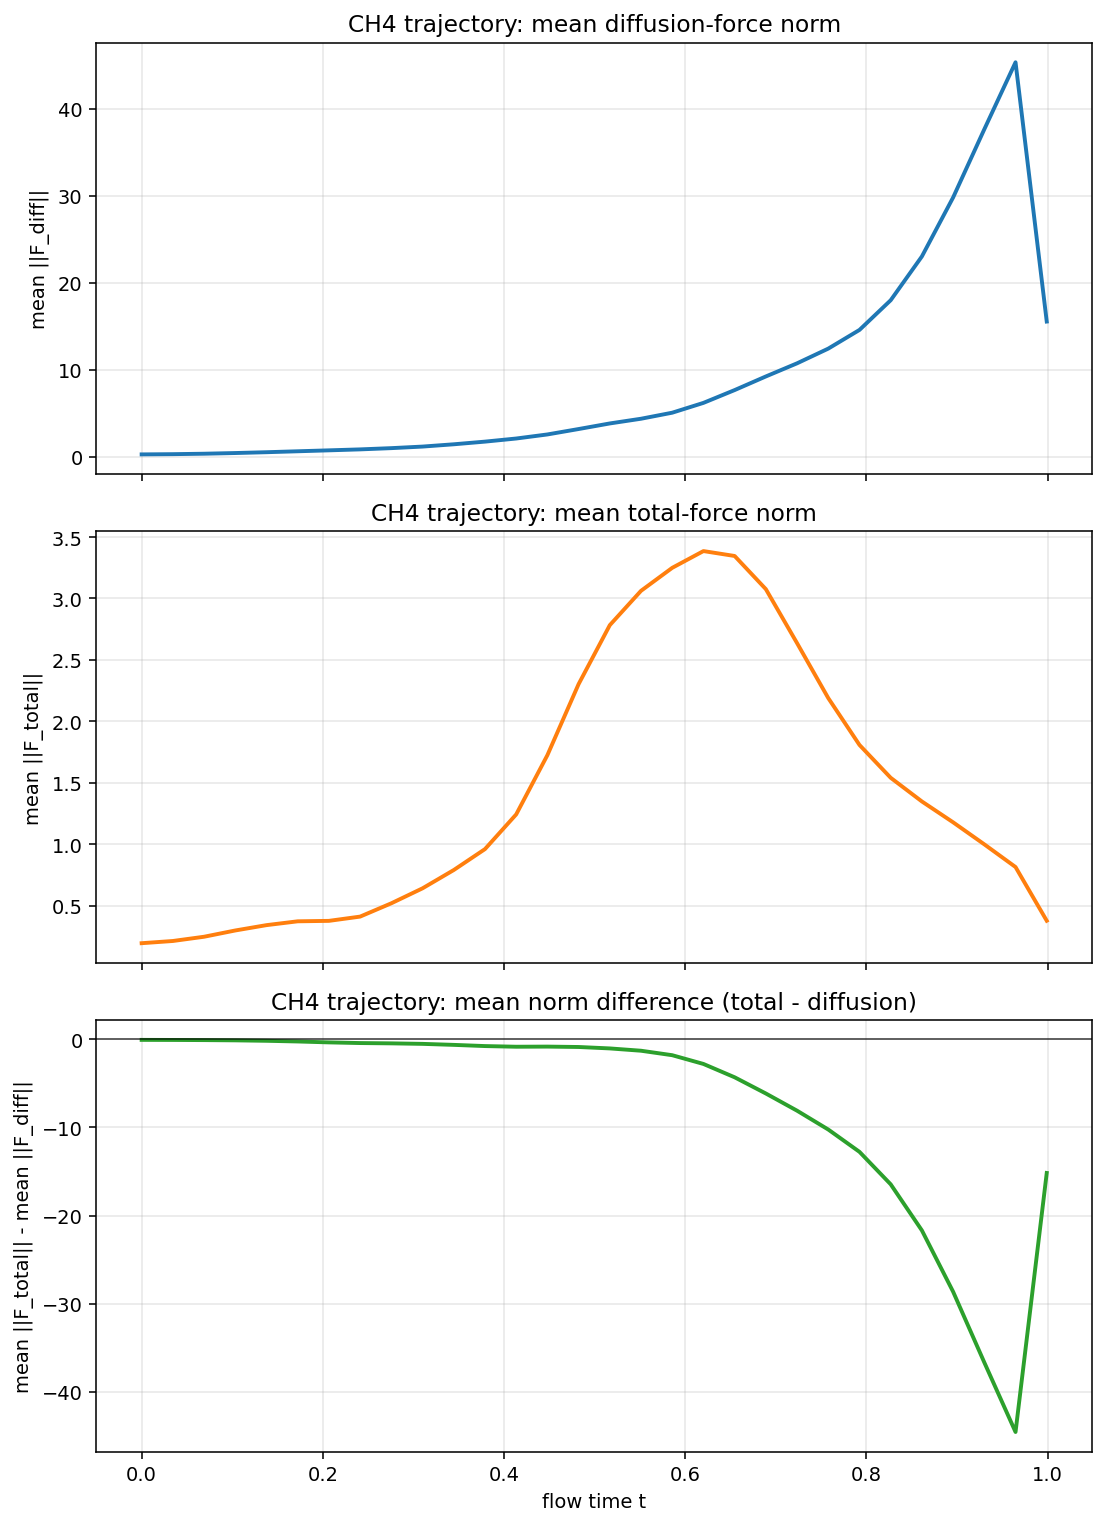

In [ ]:
# Task 6: compare diffusion-force vs total-force vector norms along a CH4 noising trajectory

CH4_TRAJ_STEPS = 30
CH4_TRAJ_TEMPERATURE = None  # None -> use model default when temperature conditioning is enabled
CH4_TRAJ_SCALE_DIFFUSION_FORCE_TO_PHYSICAL = False
CH4_TRAJ_PHYSICAL_TEMPERATURE_K = 300.0
BOLTZMANN_CONSTANT_EV_PER_K = 8.617333262145e-5

# Reuse the CH4 geometry from Task 3b as a single molecule.
ch4_clean_x = torch.tensor(CH4_XYZ, device=device, dtype=DTYPE)
ch4_batch_mask = torch.zeros(ch4_clean_x.shape[0], device=device, dtype=torch.long)
ch4_one_hot = one_hot_from_atomic_numbers(CH4_Z, model.allowed_atomic_numbers, device=device, dtype=DTYPE)

if CH4_TRAJ_SCALE_DIFFUSION_FORCE_TO_PHYSICAL:
    ch4_diffusion_force_scale = BOLTZMANN_CONSTANT_EV_PER_K * CH4_TRAJ_PHYSICAL_TEMPERATURE_K
else:
    ch4_diffusion_force_scale = 1.0

# Match model preprocessing at inference time.
if getattr(model, 'center_ligand', True):
    ch4_clean_x = center_by_batch(ch4_clean_x, ch4_batch_mask)

if model.use_temperature:
    temp_value = float(model.temperature if CH4_TRAJ_TEMPERATURE is None else CH4_TRAJ_TEMPERATURE)
    ch4_temperature = torch.full((1, 1), temp_value, device=device, dtype=DTYPE)
else:
    ch4_temperature = None

phase_fn = getattr(model, '_phase_name_for_epoch', None)
correction_active = bool(callable(phase_fn) and phase_fn() == 'correction')

# Follow the training-time boundary convention: evaluate the clean endpoint at t = 1 - t0_time_epsilon.
t0_eps = float(getattr(model, 't0_time_epsilon', 0.0))
t_end = 1.0 - max(0.0, min(1.0, t0_eps))

# Use one fixed noise realization so the states form a coherent trajectory from noisy -> nearly-clean.
eps = torch.randn_like(ch4_clean_x)
if getattr(model.module_x, 'enforce_zero_com_noise', False):
    eps = model.module_x._project_zero_com(eps, ch4_batch_mask)

t_values = torch.linspace(0.0, t_end, CH4_TRAJ_STEPS, device=device, dtype=DTYPE)
mean_force_diff_norms: list[float] = []
mean_force_total_norms: list[float] = []

with torch.no_grad():
    for t_scalar in t_values:
        t_batch = t_scalar.view(1, 1)

        # Flow time convention: t=0 is most noisy, t=1 is clean.
        # Here we stop at t_end = 1 - t0_time_epsilon to mirror boundary conditioning in training.
        if float(t_scalar.item()) >= t_end - 1e-12:
            x_state = ch4_clean_x.clone()
        else:
            tau = 1.0 - t_batch
            alpha_tau = model.module_x.alpha(tau, temperature=ch4_temperature)[ch4_batch_mask]
            sigma_tau = model.module_x.sigma(tau, temperature=ch4_temperature)[ch4_batch_mask]
            x_state = alpha_tau * ch4_clean_x + sigma_tau * eps

        pred_diff, _pred_corr, pred_total = model._forward_model_components(
            x_state,
            ch4_one_hot,
            ch4_batch_mask,
            t_batch,
            temperature=ch4_temperature,
            correction_active=correction_active,
        )

        force_diff = get_force_from_pred(
            pred_diff,
            model=model,
            x=x_state,
            batch_mask=ch4_batch_mask,
            t_flow=t_batch,
            temperature=ch4_temperature,
        ).to(dtype=torch.float32)
        force_diff = force_diff * ch4_diffusion_force_scale

        force_total = get_force_from_pred(
            pred_total,
            model=model,
            x=x_state,
            batch_mask=ch4_batch_mask,
            t_flow=t_batch,
            temperature=ch4_temperature,
        ).to(dtype=torch.float32)

        mean_force_diff_norms.append(float(torch.linalg.vector_norm(force_diff, dim=-1).mean().cpu().item()))
        mean_force_total_norms.append(float(torch.linalg.vector_norm(force_total, dim=-1).mean().cpu().item()))

t_np = t_values.detach().cpu().numpy()
diff_np = np.asarray(mean_force_diff_norms, dtype=np.float32)
total_np = np.asarray(mean_force_total_norms, dtype=np.float32)
delta_np = total_np - diff_np

print(f'Correction active: {correction_active}')
print(f'Using {CH4_TRAJ_STEPS} trajectory steps (flow time t: 0 noisy -> t_end clean-like).')
print(f't0_time_epsilon = {t0_eps:.6f} -> evaluation endpoint t_end = {t_end:.6f}')
print(f'Diffusion-force physical scaling enabled: {CH4_TRAJ_SCALE_DIFFUSION_FORCE_TO_PHYSICAL}')
print(f'Diffusion-force temperature for scaling: {CH4_TRAJ_PHYSICAL_TEMPERATURE_K:.2f} K')
print(f'Diffusion-force multiplicative scale k_B T: {ch4_diffusion_force_scale:.8f}')
print(f'Endpoint data (t={t_end:.6f}): mean ||F_diff||  = {diff_np[-1]:.6f}')
print(f'Endpoint data (t={t_end:.6f}): mean ||F_total|| = {total_np[-1]:.6f}')
print(f'Endpoint data (t={t_end:.6f}): difference       = {delta_np[-1]:.6f}')

fig, axes = plt.subplots(3, 1, figsize=(8, 11), dpi=140, sharex=True)

axes[0].plot(t_np, diff_np, color='tab:blue', linewidth=2.0)
axes[0].set_title('CH4 trajectory: mean diffusion-force norm')
axes[0].set_ylabel('mean ||F_diff||')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_np, total_np, color='tab:orange', linewidth=2.0)
axes[1].set_title('CH4 trajectory: mean total-force norm')
axes[1].set_ylabel('mean ||F_total||')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_np, delta_np, color='tab:green', linewidth=2.0)
axes[2].axhline(0.0, color='black', linewidth=1.0, alpha=0.6)
axes[2].set_title('CH4 trajectory: mean norm difference (total - diffusion)')
axes[2].set_xlabel('flow time t')
axes[2].set_ylabel('mean ||F_total|| - mean ||F_diff||')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()